In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib_venn import venn2

Total de títulos en OpenAlex: 134
Total de títulos en Scopus: 108
Total de títulos duplicados: 77
Total de títulos en Scopus que no están en OpenAlex: 31
Total de títulos en OpenAlex que no están en Scopus: 57


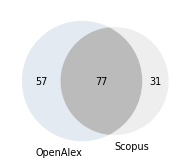

In [16]:
# Leer los archivos CSV
df_openalex = pd.read_csv('data/OpenAlex_seismic_waves_both.csv')
df_scopus = pd.read_csv('data/Scopus_seismic_waves_both.csv')

# Crear conjuntos de títulos para cada DataFrame
set_openalex = set(df_openalex['Title'])
set_scopus = set(df_scopus['Title'])

# Identificar títulos duplicados
duplicated_titles = set_openalex & set_scopus

# DataFrame con títulos duplicados (desde OpenAlex)
duplicated_df = df_openalex[df_openalex['Title'].isin(duplicated_titles)]

# Títulos únicos en cada base de datos
titles_in_openalex_not_in_scopus = set_openalex - set_scopus
titles_in_scopus_not_in_openalex = set_scopus - set_openalex

# Guardar títulos duplicados
duplicated_titles_df = pd.DataFrame(sorted(duplicated_titles), columns=['Title'])
duplicated_titles_df.to_csv('data_/duplicated_titles.csv', index=False)

# Guardar títulos únicos de OpenAlex
openalex_unique_df = df_openalex[
    df_openalex['Title'].isin(titles_in_openalex_not_in_scopus)
][['Title']]
openalex_unique_df.to_csv('data_/titles_openalex_not_in_scopus.csv', index=False)

# Guardar títulos únicos de Scopus
scopus_unique_df = df_scopus[
    df_scopus['Title'].isin(titles_in_scopus_not_in_openalex)
][['Title']]
scopus_unique_df.to_csv('data_/titles_scopus_not_in_openalex.csv', index=False)

# Imprimir totales
print(f"Total de títulos en OpenAlex: {len(set_openalex)}")
print(f"Total de títulos en Scopus: {len(set_scopus)}")
print(f"Total de títulos duplicados: {len(duplicated_titles)}")
print(f"Total de títulos en Scopus que no están en OpenAlex: {len(titles_in_scopus_not_in_openalex)}")
print(f"Total de títulos en OpenAlex que no están en Scopus: {len(titles_in_openalex_not_in_scopus)}")

color_forward = '#b9cbe0ff'   # blue w/ alpha
color_inverse = '#d6d6d683'   # gray w/ alpha

# Figure 
fig, ax = plt.subplots(figsize=(2.2, 2.2))

v = venn2(
    [set_openalex, set_scopus],
    set_labels=('OpenAlex', 'Scopus'),
    ax=ax
)

v.get_patch_by_id('10').set_color(color_forward)
v.get_patch_by_id('01').set_color(color_inverse)
v.get_patch_by_id('11').set_color('#55555580')   

for pid in ['10', '01', '11']:
    patch = v.get_patch_by_id(pid)
    if patch:
        patch.set_edgecolor('none')

for text in v.set_labels:
    if text:
        text.set_fontsize(7)

for text in v.subset_labels:
    if text:
        text.set_fontsize(7)

ax.set_axis_off()

# Save  
plt.savefig(
    'figs/duplicates.svg',
    bbox_inches='tight'
)
plt.show()

In [17]:
selected_publications = pd.read_csv('data_/selected_piml_wave_propagation_seismology_review_dataset.csv')

# Filter only journal articles
journal_articles = selected_publications[
    selected_publications["Item Type"] == "journalArticle"
]

# Count publication titles/sources
publication_counts = journal_articles["Source"].value_counts()

# Top 4 most common journals
top_4_publications = publication_counts.head(4)

# Store names and counts in variables
top_publication_names = top_4_publications.index.tolist()
top_publication_values = top_4_publications.values.tolist()

print(top_4_publications)


journal_short = [
    "IEEE TGRS",
    "JCP",
    "Geophysics",
    "Acta Geophysica",
]


# -----------------------------------------------------------------------------
# Publications per year and problem type
# -----------------------------------------------------------------------------
year_counts = (
    selected_publications
    .groupby(["Publication Year", "Problem Type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

years = year_counts.index.to_numpy()

forward_vals = (
    year_counts["Forward"].to_numpy()
    if "Forward" in year_counts.columns
    else np.zeros(len(years))
)

inverse_vals = (
    year_counts["Inverse"].to_numpy()
    if "Inverse" in year_counts.columns
    else np.zeros(len(years))
)

x = np.arange(len(years))
bar_width = 0.4

# -----------------------------------------------------------------------------
# Document types
# -----------------------------------------------------------------------------
item_type_counts = (
    selected_publications["Item Type"]
    .value_counts()
)

# -----------------------------------------------------------------------------
# Top journals
# -----------------------------------------------------------------------------
top_publications = (
    selected_publications["Source"]
    .dropna()
    .value_counts()
    .head(4)
)

top_publication_names = top_publications.index.tolist()
top_publication_values = top_publications.values

Source
IEEE Transactions on Geoscience and Remote Sensing    7
Journal of Computational Physics                      2
Geophysics                                            2
Acta Geophysica                                       2
Name: count, dtype: int64


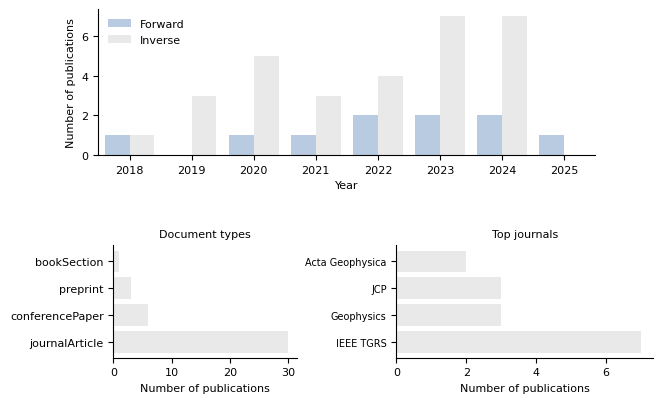

In [18]:
# -----------------------------------------------------------------------------
# Figure layout
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(6.0, 4.2))

gs = GridSpec(
    2, 2,
    height_ratios=[1.3, 1],
    width_ratios=[1, 1.4],
    figure=fig
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.12,
    top=0.95,
    hspace=0.70,
    wspace=0.45
)

# -----------------------------------------------------------------------------
# Panel A: Publications per year (full top row)
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, :])

ax1.bar(
    x - bar_width / 2,
    forward_vals,
    width=bar_width,
    color=color_forward,
    label="Forward"
)

ax1.bar(
    x + bar_width / 2,
    inverse_vals,
    width=bar_width,
    color=color_inverse,
    label="Inverse"
)

ax1.set_xticks(x)
ax1.set_xticklabels(years)

ax1.set_xlim(-0.5, len(years) - 0.5)

ax1.set_ylabel("Number of publications", fontsize=8)
ax1.set_xlabel("Year", fontsize=8)

#ax1.set_xticks(np.arange(min(years), max(years) + 1, 1))
#ax1.set_xlim(min(years) - 0.5, max(years) + 0.5)

ax1.tick_params(axis='both', labelsize=8)

ax1.legend(
    frameon=False,
    fontsize=8,
    loc='upper left'
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# Move top panel slightly to the left
# -----------------------------------------------------------------------------
pos = ax1.get_position()

ax1.set_position([
    pos.x0 - 0.025,      # move left
    pos.y0,
    pos.width * 0.92,    # reduce width
    pos.height
])

# -----------------------------------------------------------------------------
# Panel B: Document types (bottom left)
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])

item_order = np.argsort(item_type_counts.values)

ax2.barh(
    item_type_counts.index[item_order],
    item_type_counts.values[item_order],
    color=color_inverse
)

ax2.set_title("Document types", fontsize=8)
ax2.set_xlabel("Number of publications", fontsize=8)

ax2.tick_params(axis='x', labelsize=8)
ax2.tick_params(axis='y', labelsize=8)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# Panel C: Top journals (bottom right)
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 1])

journal_order = np.argsort(top_publication_values)

ax3.barh(
    np.array(journal_short)[journal_order],
    np.array(top_publication_values)[journal_order],
    color=color_inverse
)

ax3.set_title("Top journals", fontsize=8)
ax3.set_xlabel("Number of publications", fontsize=8)

ax3.tick_params(axis='x', labelsize=8)
ax3.tick_params(axis='y', labelsize=7)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# Show largest category at top
# -----------------------------------------------------------------------------
ax2.invert_yaxis()
ax3.invert_yaxis()

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------
plt.savefig(
    "figs/item_types_and_publications_per_year.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figs/item_types_and_publications_per_year.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()